import libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from prophet import Prophet



load dataset

In [44]:
sales = pd.read_csv("restaurant_sales.csv", parse_dates=["date"])
weather = pd.read_csv("Daily_Weather_Insights.csv", parse_dates=["Date"])
holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])

/tmp/ipykernel_8797/2494791094.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])


In [45]:
weather.rename(columns={"Date":"date"}, inplace=True)
holidays.rename(columns={"Date":"date"}, inplace=True)

In [46]:
print(sales.head(5))

        date   sales
0 2025-01-01  281.64
1 2025-01-02  212.74
2 2025-01-03  250.61
3 2025-01-04  253.38
4 2025-01-05  253.00


In [47]:
sales.index=sales['date']

In [48]:
print(sales.head(5))

                 date   sales
date                         
2025-01-01 2025-01-01  281.64
2025-01-02 2025-01-02  212.74
2025-01-03 2025-01-03  250.61
2025-01-04 2025-01-04  253.38
2025-01-05 2025-01-05  253.00


In [49]:
del sales['date']

In [50]:
print(sales.head(5))

             sales
date              
2025-01-01  281.64
2025-01-02  212.74
2025-01-03  250.61
2025-01-04  253.38
2025-01-05  253.00


In [51]:
sales.isnull().sum().sum()

0

In [52]:
sales.duplicated().sum()

6

In [53]:
sales.drop_duplicates(inplace=True)

In [54]:
sales.duplicated().sum()

0

In [55]:
print(weather.head(5))

        date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0 2025-01-01  Cairo                   16.9                  14.1   
1 2025-01-02  Cairo                   15.1                   5.6   
2 2025-01-03  Cairo                   25.1                  18.2   
3 2025-01-04  Cairo                   28.9                   9.9   
4 2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2                

In [56]:
weather.index=weather['date']

In [57]:
del weather['date']

In [58]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

In [59]:
weather.isnull().sum().sum()

0

In [60]:
weather.duplicated().sum()

0

In [61]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [62]:
print(holidays.head(5))

  Country  Year                 date               Holiday_Name  Local_Name  \
0      IN  2025  2025-01-01 00:00:00             New Year's Day         NaN   
1      IN  2025  2025-02-01 00:00:00       Last day of Hanukkah         NaN   
2      IN  2025  2025-06-01 00:00:00  Guru Govind Singh Jayanti         NaN   
3      IN  2025  2025-01-13 00:00:00                      Lohri         NaN   
4      IN  2025  2025-01-14 00:00:00                     Pongal         NaN   

                         Type  
0            Optional holiday  
1                  Observance  
2            Optional holiday  
3                  Observance  
4  Hinduism, Optional holiday  


In [63]:
holidays['date'] = pd.to_datetime(holidays['date'], format='%Y-%m-%d', errors='coerce')

In [64]:
holidays = holidays[holidays['date'].between('2025-01-01','2028-12-31')]

In [65]:
holidays.index=holidays['date']

In [66]:
del holidays['date']
del holidays['Local_Name']


In [67]:
del holidays['Year']

In [68]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2025-01-01 to 2025-03-14
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       19 non-null     object
 1   Holiday_Name  19 non-null     object
 2   Type          19 non-null     object
dtypes: object(3)
memory usage: 608.0+ bytes


In [69]:
holidays.isnull().sum().sum()

0

In [70]:
holidays.duplicated().sum()

0

In [71]:
holidays.shape

(19, 3)

In [72]:
# Merge sales with weather and holidays
df = sales.merge(weather, on="date", how="left")
df = df.merge(holidays, on="date", how="left")



In [73]:
df.head(5)

,sales,City,Temperature_High (°C),Temperature_Low (°C),Humidity (%),Wind_Speed (km/h),Weather_Condition,Air_Quality_Index,Precipitation (mm),Visibility (km),Country,Holiday_Name,Type
date,,,,,,,,,,,,,
2025-01-01,281.64,Cairo,16.9,14.1,43.1,24.2,Sunny,145.0,17.2,4.7,IN,New Year's Day,Optional holiday
2025-01-02,212.74,Cairo,15.1,5.6,56.9,8.2,Windy,115.0,0.5,9.8,NaN,NaN,NaN
2025-01-03,250.61,Cairo,25.1,18.2,52.5,18.2,Snowy,11.0,6.0,2.5,NaN,NaN,NaN
2025-01-04,253.38,Cairo,28.9,9.9,76.3,18.8,Rainy,22.0,6.8,9.4,NaN,NaN,NaN
2025-01-05,253.00,Cairo,17.6,13.7,55.6,10.8,Sunny,39.0,12.6,4.5,NaN,NaN,NaN


In [74]:
df['Country'].unique()

array(['IN', nan], dtype=object)

In [75]:
df['Country'] = df['Country'].fillna('IN')
df['Holiday_Name'] = df['Holiday_Name'].fillna('No Holiday')
df['Type'] = df['Type'].fillna('No Type')

In [76]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print(df.isnull().sum().sum())

540


In [77]:
df.dropna(inplace=True)

In [78]:
print(df.columns)

Index(['sales', 'City', 'Temperature_High (°C)', 'Temperature_Low (°C)',
       'Humidity (%)', 'Wind_Speed (km/h)', 'Weather_Condition',
       'Air_Quality_Index', 'Precipitation (mm)', 'Visibility (km)', 'Country',
       'Holiday_Name', 'Type'],
      dtype='object')


In [79]:
df['sales_stationay'] = df['sales'].diff(periods=1)
df['sales_stationay'] = df['sales_stationay'].fillna(0)

from statsmodels.tsa.stattools import adfuller

if not df['sales_stationay'].empty:
  result=adfuller(df['sales_stationay'])
  p_value=result[1]
  if p_value < 0.05:
    print("accepted as stationary")
  else:
    print("rejected as non stationary")
else:
  print("Cannot perform ADFuller test: 'sales_stationay' series is empty after data processing.")

accepted as stationary


In [80]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)
df["is_holiday"] = df["Holiday_Name"].notnull().astype(int)
df['day']=df.index.day

In [81]:
#lag feature
df['sales_lag_1'] = df['sales'].shift(1)
df['sales_lag_2'] = df['sales'].shift(7)

In [82]:
df['sales_lag_1'] = df['sales_lag_1'].fillna(0)
df['sales_lag_2'] = df['sales_lag_2'].fillna(0)

In [83]:
#rolling avg feature
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_14'] = df['sales'].rolling(window=14).mean()

In [84]:
# Optional: cap extreme outliers (holiday spikes)
q_low, q_high = sales['sales'].quantile([0.01, 0.99])
sales['sales'] = np.clip(sales['sales'], q_low, q_high)

In [85]:
#sales numbers to stay strictly within outlier(adding treshold)
df['sales_capped']=df['sales'].clip(lower=q_low,upper=q_high)

In [86]:
df['log_sales'] = np.log(df['sales'])

In [87]:
#if u used log
df['sales_diff1'] = df['log_sales'].diff(periods=1)
#if u did not use log
df['sales_diff1'] = df['sales'].diff(periods=1)

In [88]:
df['sales_stationay'] = df['sales'].diff(periods=1)

In [89]:
df['rolling_mean_7'] = df['rolling_mean_7'].fillna(0)
df['rolling_mean_14'] = df['rolling_mean_14'].fillna(0)
df['sales_diff1'] = df['sales_diff1'].fillna(0)
df['sales_stationay'] = df['sales_stationay'].fillna(0)

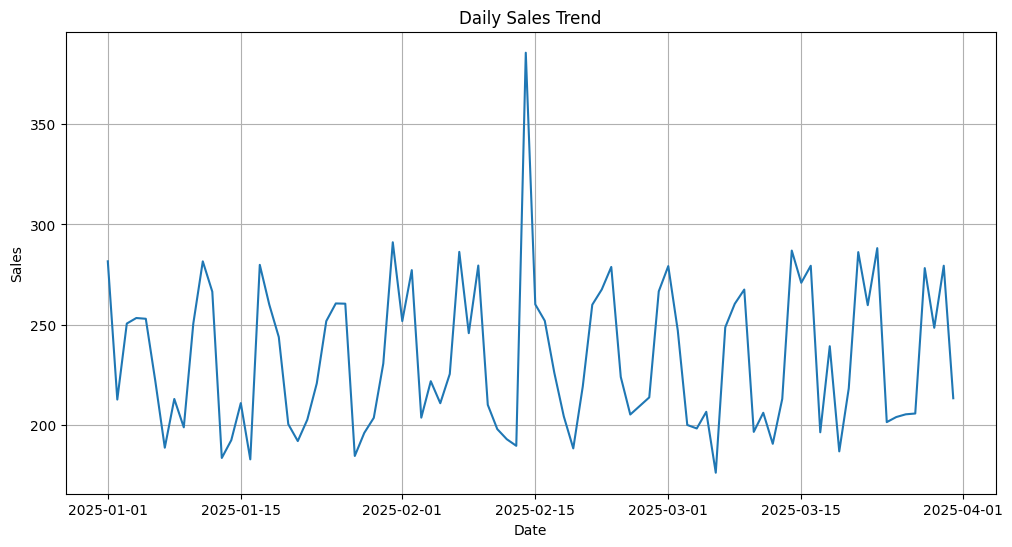

In [90]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

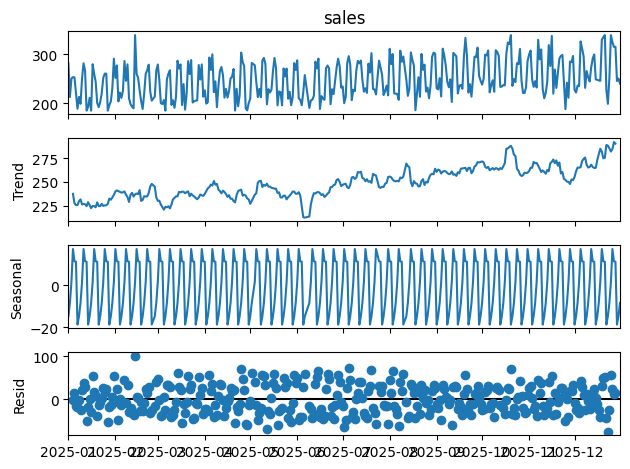

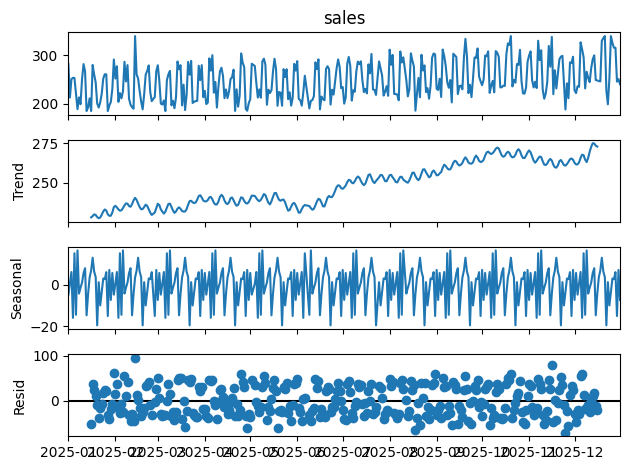

In [91]:
# eda: decompose seasonality (weekly pattern)
result = seasonal_decompose(sales['sales'], model='additive', period=7)
result.plot()
plt.show()

# Monthly decomposition (if dataset spans >1 year)
result_month = seasonal_decompose(sales['sales'], model='additive', period=30)
result_month.plot()
plt.show()


<Figure size 1200x400 with 0 Axes>

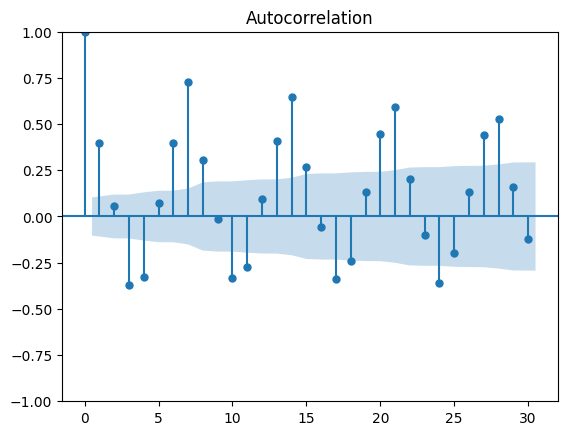

<Figure size 1200x400 with 0 Axes>

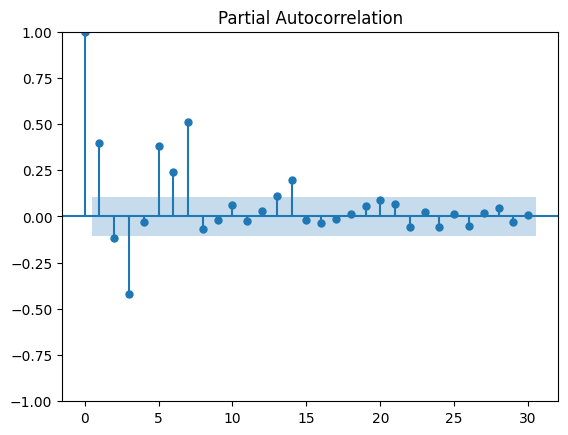

In [92]:
# eda: autocorrelation & partial autocorrelation
plt.figure(figsize=(12,4))
plot_acf(sales['sales'].dropna(), lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sales['sales'].dropna(), lags=30)
plt.show()


In [93]:
x=df.drop('sales',axis=1)
y=df['sales']

In [100]:
from statsmodels.tsa.arima.model import ARIMA

# Ensure the time series has a unique index and daily frequency
# Aggregate sales for duplicate dates by summing them up
y = y.resample('D').sum()

# Split data into train and test sets (80/20 split)
# y is a Series of length 92
train_size = int(len(y) * 0.8)
train, test = y[0:train_size], y[train_size:]

model=ARIMA(train,order=(1,0,1))
model_fit=model.fit()

In [118]:
predictions = model_fit.predict(start=len(train), end=len(y)-1)

# Ensure predictions and test set have the same length and index for direct comparison
# (This is important if 'test' had any missing dates that 'predict' might not account for directly)
predictions.index = test.index

# Calculate RMSE for ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, predictions))
print(f'ARIMA Root Mean Squared Error (RMSE): {rmse_arima:.2f}')

# Calculate MAE for ARIMA
mae_arima = mean_absolute_error(test, predictions)
print(f'ARIMA Mean Absolute Error (MAE): {mae_arima:.2f}')

ARIMA Root Mean Squared Error (RMSE): 85.57
ARIMA Mean Absolute Error (MAE): 49.39


In [97]:
!pip install numpy==1.26.4

In [101]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.4 MB/s eta 0:00:00


In [102]:
from pmdarima import auto_arima

In [103]:
# Log transformation of sales
df['log_sales'] = np.log(df['sales'].replace(0, np.nan).fillna(method='ffill')) # Handle potential zeros before log

/tmp/ipykernel_8797/3047013811.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['log_sales'] = np.log(df['sales'].replace(0, np.nan).fillna(method='ffill')) # Handle potential zeros before log


In [105]:
# First differencing
df['sales_diff1'] = df['log_sales'].diff(periods=1)
df['sales_diff1'] = df['sales_diff1'].fillna(0)

In [106]:
# Seasonal differencing for stationarity
df['sales_stationay']=df['sales_diff1'].diff(periods=7)
df['sales_stationay'] = df['sales_stationay'].fillna(0)

In [107]:
# Final check for NaNs before ADFuller test
print("Total NaN values before ADFuller test:", df.isnull().sum().sum())

Total NaN values before ADFuller test: 0


In [119]:
# Prepare holidays DataFrame for Prophet
prophet_holidays = holidays.reset_index()[['date', 'Holiday_Name']]
prophet_holidays = prophet_holidays.rename(columns={'date': 'ds', 'Holiday_Name': 'holiday'})
# Prophet can also take `lower_window` and `upper_window` columns if holidays have duration
prophet_holidays['lower_window'] = 0
prophet_holidays['upper_window'] = 0

display(prophet_holidays.head())

,ds,holiday,lower_window,upper_window
0,2025-01-01,New Year's Day,0,0
1,2025-02-01,Last day of Hanukkah,0,0
2,2025-06-01,Guru Govind Singh Jayanti,0,0
3,2025-01-13,Lohri,0,0
4,2025-01-14,Pongal,0,0


In [108]:
from statsmodels.tsa.stattools import adfuller

if not df['sales_stationay'].empty:
  result=adfuller(df['sales_stationay'])
  p_value=result[1]
  if p_value < 0.05:
    print("accepted as stationary")
  else:
    print("rejected as non stationary")
else:
  print("Cannot perform ADFuller test: 'sales_stationay' series is empty after data processing.")

accepted as stationary


In [111]:
# Prophet model (seasonality + trend)
prophet_df = df.reset_index()[["date","sales"]].rename(columns={"date":"ds","sales":"y"})
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet.fit(prophet_df)

In [120]:
# Re-initialize Prophet model with holidays
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=prophet_holidays # Pass the prepared holidays DataFrame here
)
prophet.fit(prophet_df)

In [113]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical features (using 'City' as 'store_id' does not exist)
store_encoder = LabelEncoder()
df["city_enc"] = store_encoder.fit_transform(df["City"])

# Scale continuous features
scaler = StandardScaler()
df[["sales","Temperature_High (°C)","Temperature_Low (°C)","Precipitation (mm)"]] = scaler.fit_transform(df[["sales","Temperature_High (°C)","Temperature_Low (°C)","Precipitation (mm)"]])

In [128]:
df_unscaled = sales.merge(weather, on='date', how='left')

### Impact of Weather Variables on Sales

Let's visualize the relationship between sales and various weather conditions using scatter plots. We will look at temperature, humidity, wind speed, precipitation, and air quality index.

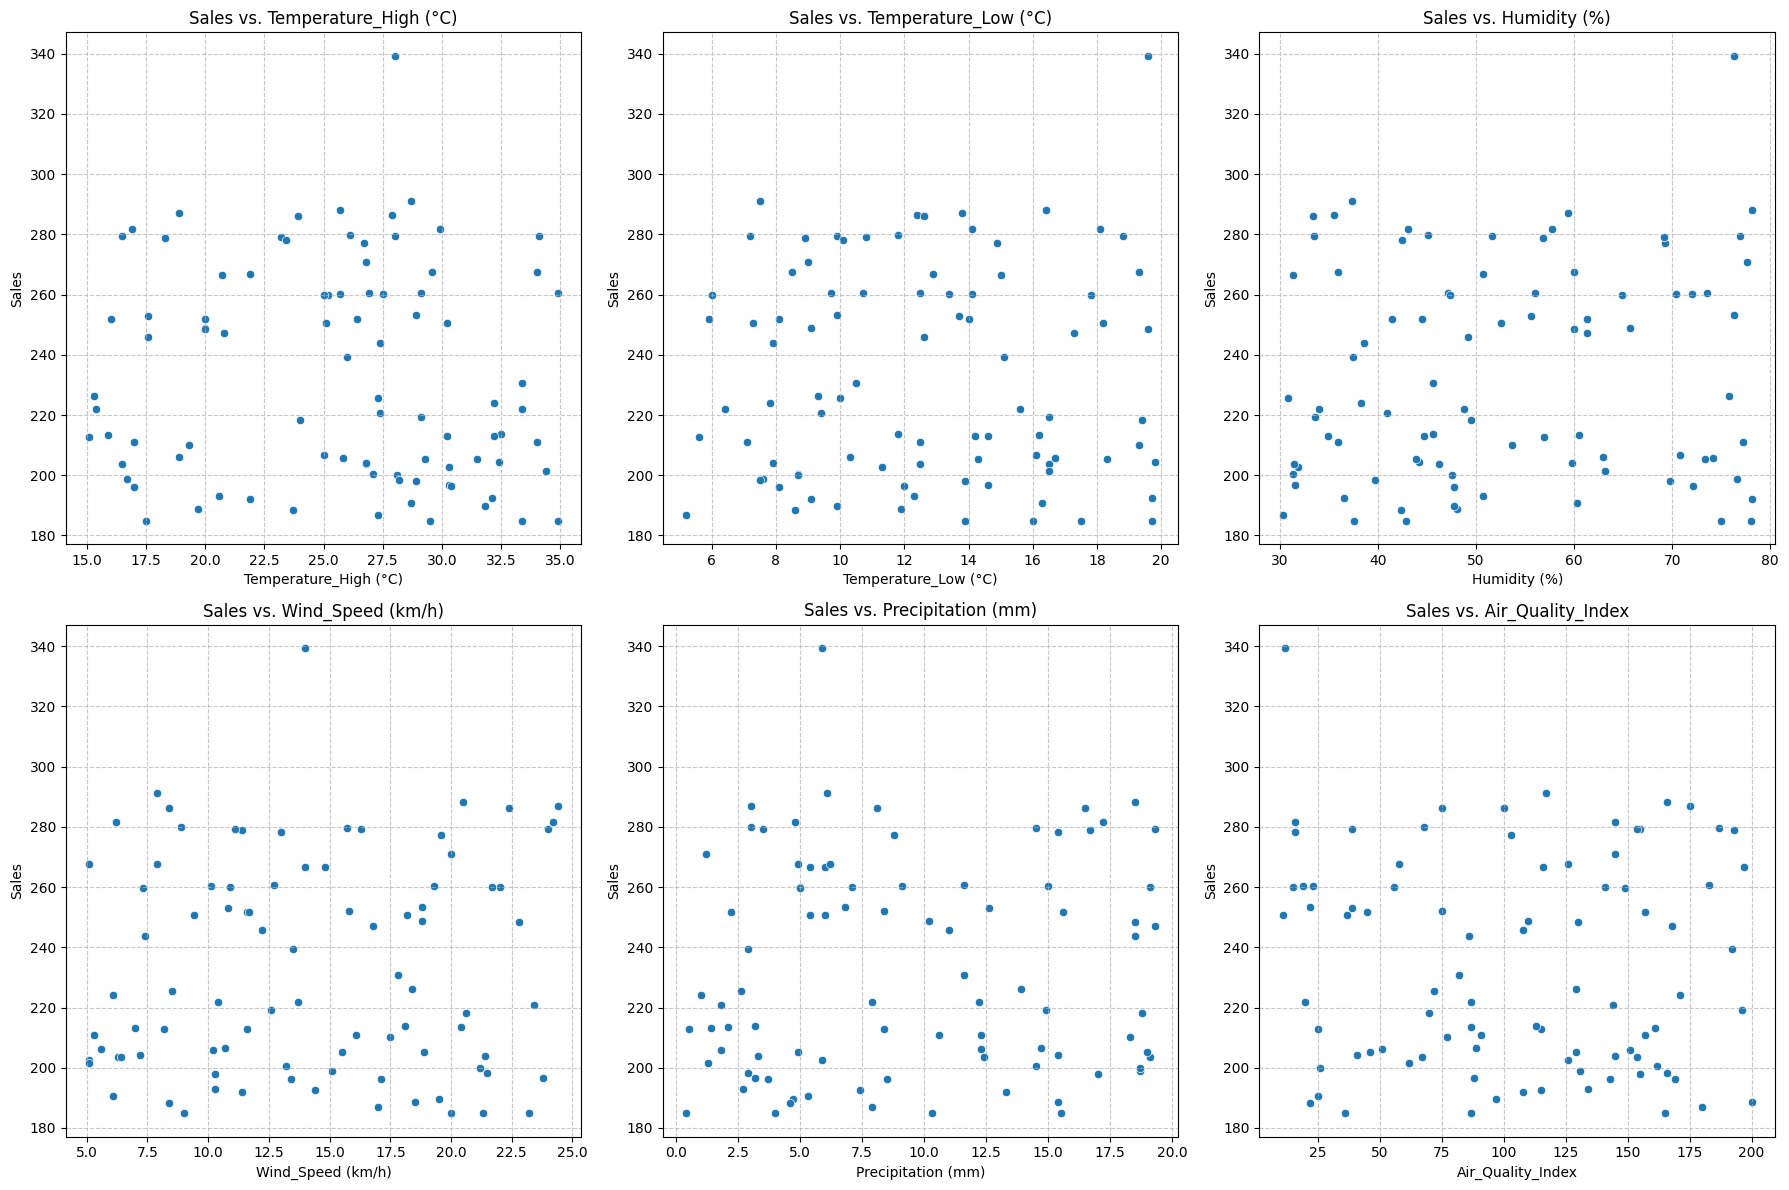

In [129]:
weather_cols = [
    'Temperature_High (°C)', 'Temperature_Low (°C)', 'Humidity (%)',
    'Wind_Speed (km/h)', 'Precipitation (mm)', 'Air_Quality_Index'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(weather_cols):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=df_unscaled[col], y=df_unscaled['sales'])
    plt.title(f'Sales vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [130]:
# Select sales and weather columns from the unscaled DataFrame
correlation_data = df_unscaled[['sales'] + weather_cols]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Display the correlation matrix, focusing on sales correlation with weather variables
display(correlation_matrix['sales'].drop('sales').sort_values(ascending=False))

,sales
Humidity (%),0.110549
Precipitation (mm),0.078764
Wind_Speed (km/h),0.061773
Temperature_Low (°C),0.007669
Air_Quality_Index,-0.069500
Temperature_High (°C),-0.088803


In [123]:
import joblib

In [131]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Create a copy of the engineered DataFrame (df) for regression analysis
# This `df` contains features after cleaning, engineering, and dropping NaNs.
regression_analysis_df = df.copy()

# Replace the scaled 'sales' column with the original 'sales' values for the regression target
# This ensures interpretability of coefficients in terms of actual sales dollars.
regression_analysis_df['sales'] = sales.loc[regression_analysis_df.index, 'sales']

# Define the target variable
target = 'sales'

# Define features (X)
# Include relevant numerical features (weather, temporal, lag, rolling means)
numerical_features_for_reg = [
    'Temperature_High (°C)', 'Temperature_Low (°C)', 'Humidity (%)',
    'Wind_Speed (km/h)', 'Precipitation (mm)', 'Air_Quality_Index', 'Visibility (km)',
    'day_of_week', 'month', 'is_weekend', 'is_holiday', 'day',
    'sales_lag_1', 'sales_lag_2', 'rolling_mean_7', 'rolling_mean_14'
]

# Define categorical features that will be one-hot encoded
categorical_features_for_reg = ['City', 'Weather_Condition', 'Country', 'Holiday_Name', 'Type']

# Create X (features) and y (target)
X_reg = regression_analysis_df[numerical_features_for_reg + categorical_features_for_reg].copy()
y_reg = regression_analysis_df[target]

# One-hot encode categorical features to make them suitable for linear regression
X_reg = pd.get_dummies(X_reg, columns=categorical_features_for_reg, drop_first=True)

# Align indices of X and y to ensure they match perfectly after any operations
X_reg, y_reg = X_reg.align(y_reg, join='inner', axis=0)

# Split data into training and testing sets using TimeSeriesSplit
# This maintains the temporal order of the data.
tscv = TimeSeriesSplit(n_splits=5)
# Iterate through splits to get the last train/test split for evaluation
for train_index, test_index in tscv.split(X_reg):
    X_train, X_test = X_reg.iloc[train_index], X_reg.iloc[test_index]
    y_train, y_test = y_reg.iloc[train_index], y_reg.iloc[test_index]

# Initialize and train the Linear Regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_lr.predict(X_test)

# Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression Model Performance on Test Set:")
print(f"  RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"  MAE (Mean Absolute Error): {mae:.2f}")

# Display coefficients to interpret feature importance
coefficients_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model_lr.coef_})
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

print("\nTop 10 Positive Coefficients (Features that increase sales):")
display(coefficients_df.head(10))

print("\nTop 10 Negative Coefficients (Features that decrease sales):")
display(coefficients_df.tail(10))

Linear Regression Model Performance on Test Set:
  RMSE (Root Mean Squared Error): 20.64
  MAE (Mean Absolute Error): 18.77

Top 10 Positive Coefficients (Features that increase sales):


,Feature,Coefficient
34,Holiday_Name_Valentine's Day,96.412993
28,Holiday_Name_New Year's Day,85.079508
37,"Type_National holiday, Hinduism",15.226089
21,Holiday_Name_Holi,15.226089
40,Type_Optional holiday,14.599218
7,day_of_week,11.768477
8,month,11.626764
35,Holiday_Name_Vasant Panchami,5.085196
30,Holiday_Name_Pongal,3.309051
4,Precipitation (mm),2.878926



Top 10 Negative Coefficients (Features that decrease sales):


,Feature,Coefficient
16,Weather_Condition_Rainy,-17.553702
32,Holiday_Name_Republic Day,-17.901153
36,Type_National holiday,-17.901153
19,Weather_Condition_Windy,-22.973898
23,Holiday_Name_Last day of Hanukkah,-26.910763
24,Holiday_Name_Lohri,-29.400479
26,Holiday_Name_Maharishi Dayanand Saraswati Jayanti,-40.488809
25,Holiday_Name_Lunar New Year,-42.786406
22,Holiday_Name_Holika Dahana,-49.095572
33,Holiday_Name_Shivaji Jayanti,-73.855436


In [124]:
# Save the Prophet model with holidays
model_filename = 'prophet_model_with_holidays.joblib'
joblib.dump(prophet, model_filename)
print(f'Prophet model saved to {model_filename}')

Prophet model saved to prophet_model_with_holidays.joblib


In [125]:
# Load the saved Prophet model
loaded_prophet_model = joblib.load(model_filename)
print(f'Prophet model loaded from {model_filename}')

Prophet model loaded from prophet_model_with_holidays.joblib


In [126]:
# Create a future DataFrame for forecasting (e.g., 30 days into the future)
# Ensure the last date in prophet_df is used as the starting point for make_future_dataframe
# prophet_df has already been created and used to train the model.
future_dates = loaded_prophet_model.make_future_dataframe(periods=30, freq='D')

# Generate the forecast
future_forecast = loaded_prophet_model.predict(future_dates)

# Display the relevant parts of the future forecast
display(future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
114,2025-04-26,4155.415752,4140.673346,4169.958608
115,2025-04-27,4233.804856,4220.323708,4247.468434
116,2025-04-28,4204.723007,4190.167512,4220.086421
117,2025-04-29,4186.029221,4172.133267,4199.750698
118,2025-04-30,4116.601723,4102.121445,4130.805326


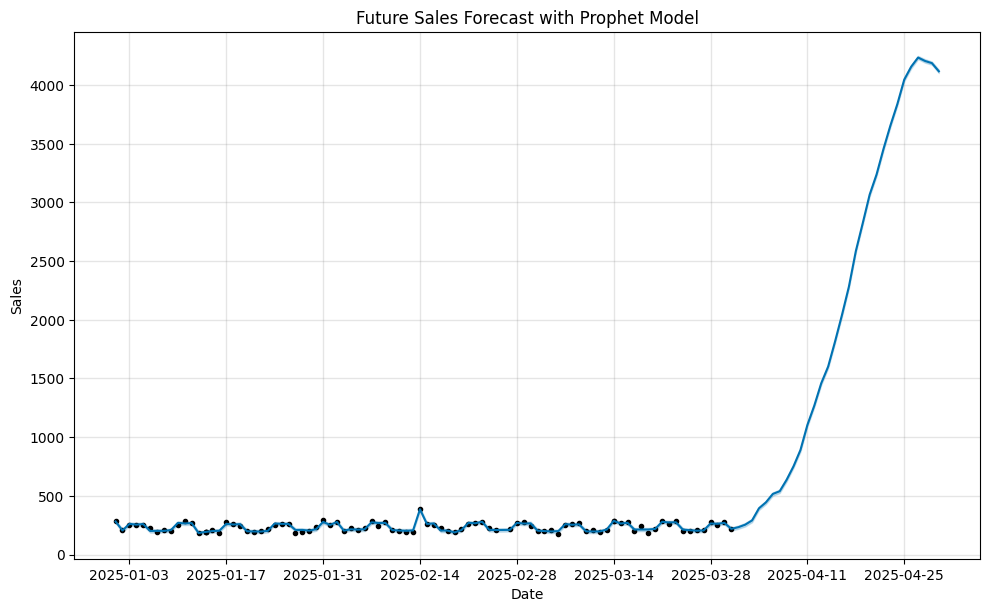

In [127]:
# Plot the forecast
fig = loaded_prophet_model.plot(future_forecast)
plt.title('Future Sales Forecast with Prophet Model')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [116]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Extract historical predictions from the forecast DataFrame
historical_forecast = forecast[forecast['ds'].isin(prophet_df['ds'])]

# Merge actuals with predictions for easy comparison
performance_df = prophet_df.merge(historical_forecast[['ds', 'yhat']], on='ds', how='left')

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(performance_df['y'], performance_df['yhat']))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Calculate MAE
mae = mean_absolute_error(performance_df['y'], performance_df['yhat'])
print(f'Mean Absolute Error (MAE): {mae:.2f}')

Root Mean Squared Error (RMSE): 17.16
Mean Absolute Error (MAE): 11.83


In [122]:
# Re-calculate RMSE and MAE for the updated Prophet model
historical_forecast = forecast[forecast['ds'].isin(prophet_df['ds'])]
performance_df = prophet_df.merge(historical_forecast[['ds', 'yhat']], on='ds', how='left')

rmse_prophet_holidays = np.sqrt(mean_squared_error(performance_df['y'], performance_df['yhat']))
print(f'Prophet (with Holidays) Root Mean Squared Error (RMSE): {rmse_prophet_holidays:.2f}')

mae_prophet_holidays = mean_absolute_error(performance_df['y'], performance_df['yhat'])
print(f'Prophet (with Holidays) Mean Absolute Error (MAE): {mae_prophet_holidays:.2f}')

Prophet (with Holidays) Root Mean Squared Error (RMSE): 11.04
Prophet (with Holidays) Mean Absolute Error (MAE): 8.33


In [114]:
future = prophet.make_future_dataframe(periods=30, freq='D')
forecast = prophet.predict(future)
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
114,2025-04-26,3648.816291,3628.228605,3671.390000
115,2025-04-27,3723.727600,3701.416277,3745.366986
116,2025-04-28,3694.200191,3670.666128,3716.438281
117,2025-04-29,3687.592951,3665.904446,3710.391856
118,2025-04-30,3640.962141,3619.977232,3664.614792


In [121]:
# Re-generate forecast with the updated Prophet model
future = prophet.make_future_dataframe(periods=30, freq='D')
forecast = prophet.predict(future)
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
114,2025-04-26,4155.415752,4141.243796,4170.206513
115,2025-04-27,4233.804856,4220.033546,4248.637081
116,2025-04-28,4204.723007,4189.891600,4218.710956
117,2025-04-29,4186.029221,4170.706270,4199.737612
118,2025-04-30,4116.601723,4102.386692,4130.853316


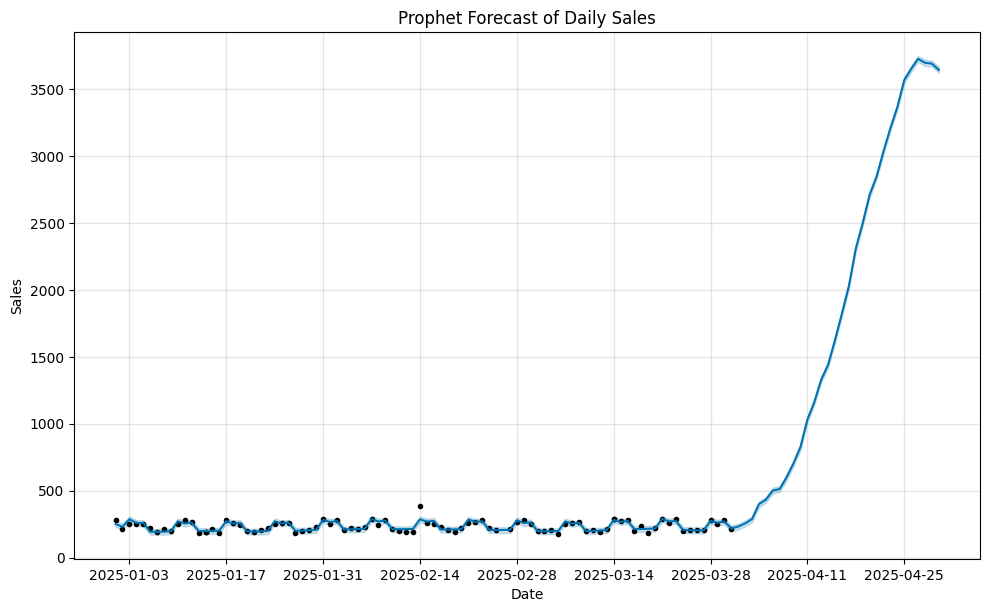

In [115]:
fig1 = prophet.plot(forecast)
plt.title('Prophet Forecast of Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

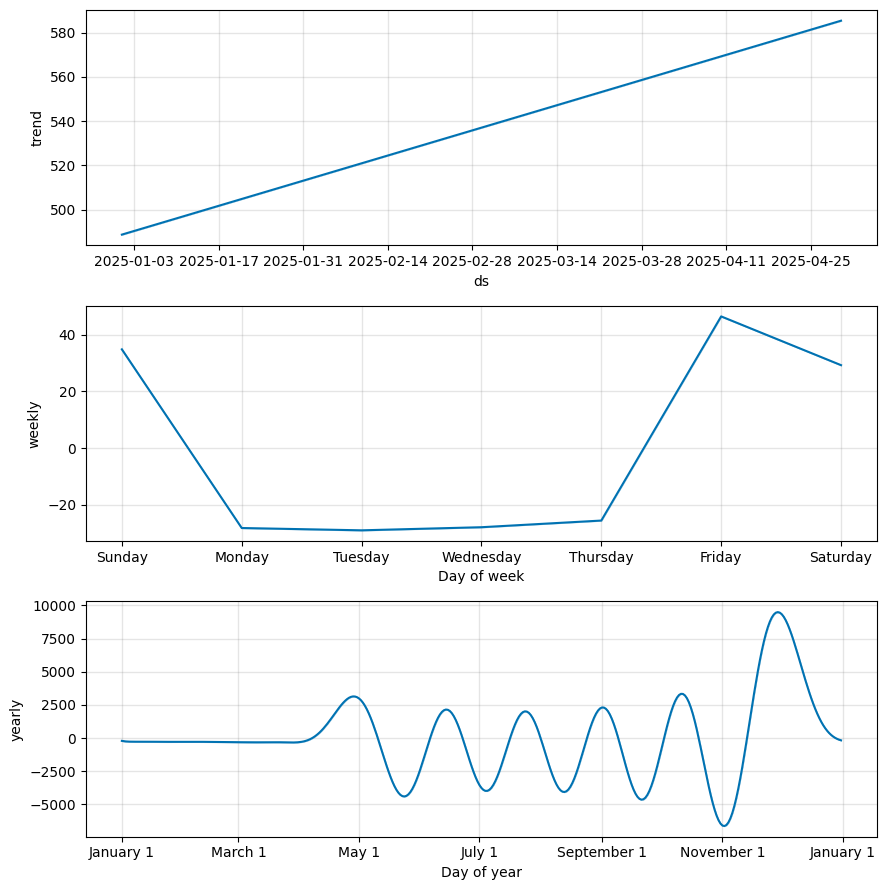

In [117]:
fig2 = prophet.plot_components(forecast)
plt.show()

In [134]:
model = joblib.load("prophet_model_with_holidays.joblib")
forecast = model.predict(future)

In [136]:
from fastapi import FastAPI
import joblib

app = FastAPI()
model = joblib.load("prophet_model_with_holidays.joblib")

@app.get("/predict")
def predict(days: int = 30):
    future = model.make_future_dataframe(periods=days)
    forecast = model.predict(future)
    return forecast.tail(days).to_dict("records")
